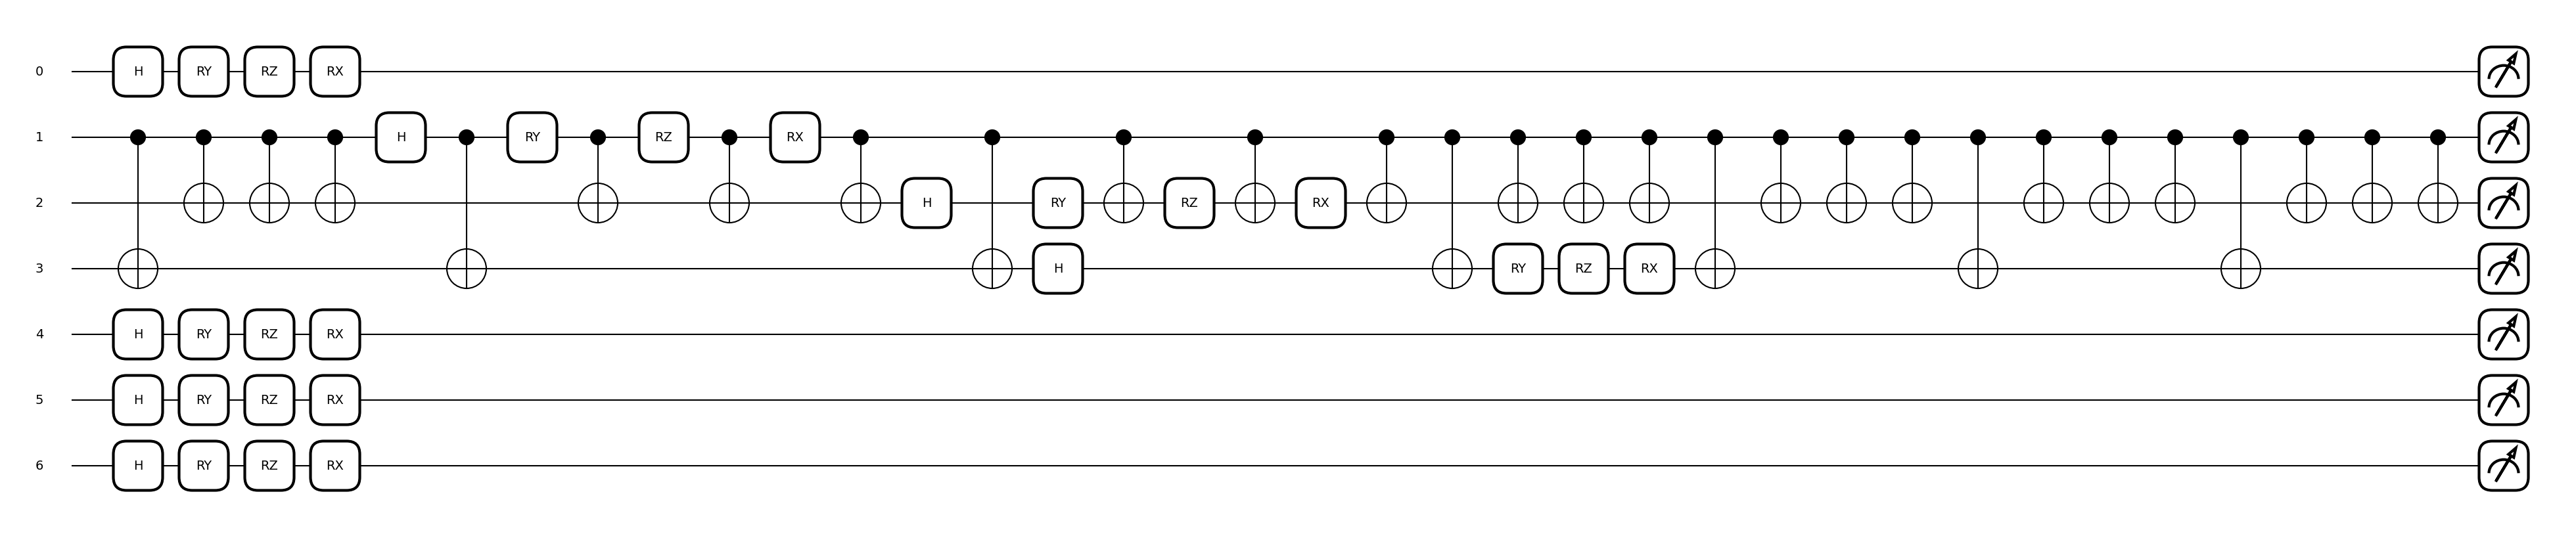

In [1]:
import pennylane as qml
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
# Sample training data
import lightgbm as lgb
import pandas as pd
import numpy as np
import pennylane as qml
from pennylane import numpy as np
from sklearn.svm import SVR

df=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\1002-ORIGIN-2D electronic properties2.csv",encoding='ISO-8859–1')      
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y = df['Band gap ']

# defining target
x=df[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]



# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x)

# Quantum setup
n_qubits = 7
dev = qml.device("default.qubit", wires=n_qubits)

# Define quantum feature map
def quantum_feature_map(x):
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        qml.CNOT(wires=[1, 3])
        qml.RY(np.pi,wires=i)
        qml.CNOT(wires=[1, 2])
        qml.RZ(x[i % len(x)], wires=i)
        qml.CNOT(wires=[1, 2])
        qml.RX(np.pi*1.5, wires=i)
        qml.CNOT(wires=[1, 2])

# Define a quantum node
@qml.qnode(dev)
def circuit(x):
    quantum_feature_map(x)
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

# Visualize the quantum circuit for a sample
sample_x = X_train_scaled[0][:n_qubits]  # Take the first training sample, limit to `n_qubits`

# Draw the circuit using matplotlib
fig, ax = qml.draw_mpl(circuit)(sample_x)
plt.show()


In [2]:
y_train=(y)

In [3]:
# Quantum kernel function
@qml.qnode(dev)
def quantum_kernel(x1, x2):
    quantum_feature_map(x1)
    qml.adjoint(quantum_feature_map)(x2)
    return qml.probs(wires=range(n_qubits))
# Compute the kernel matrix for input data
def compute_kernel_matrix(X):
    n_samples = len(X)
    kernel_matrix = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        for j in range(n_samples):
            # Directly access the probability value (first element)
            kernel_matrix[i, j] = quantum_kernel(X[i], X[j])[0]
    return kernel_matrix
# Compute the quantum kernel matrix for training
K_train = compute_kernel_matrix(X_train_scaled)

# Train the SVR with a precomputed kernel matrix
svr = SVR(kernel='precomputed', epsilon=0.07491851902055541,C=977,gamma=2.0881963569756823)
svr.fit(K_train, y_train)



,kernel,'precomputed'
,degree,3
,gamma,2.0881963569756823
,coef0,0.0
,tol,0.001
,C,977
,epsilon,0.07491851902055541
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


train r^2: 0.9987175795812603
train MAE 0.042728982245492764
train RMSE: 0.049421103231279094


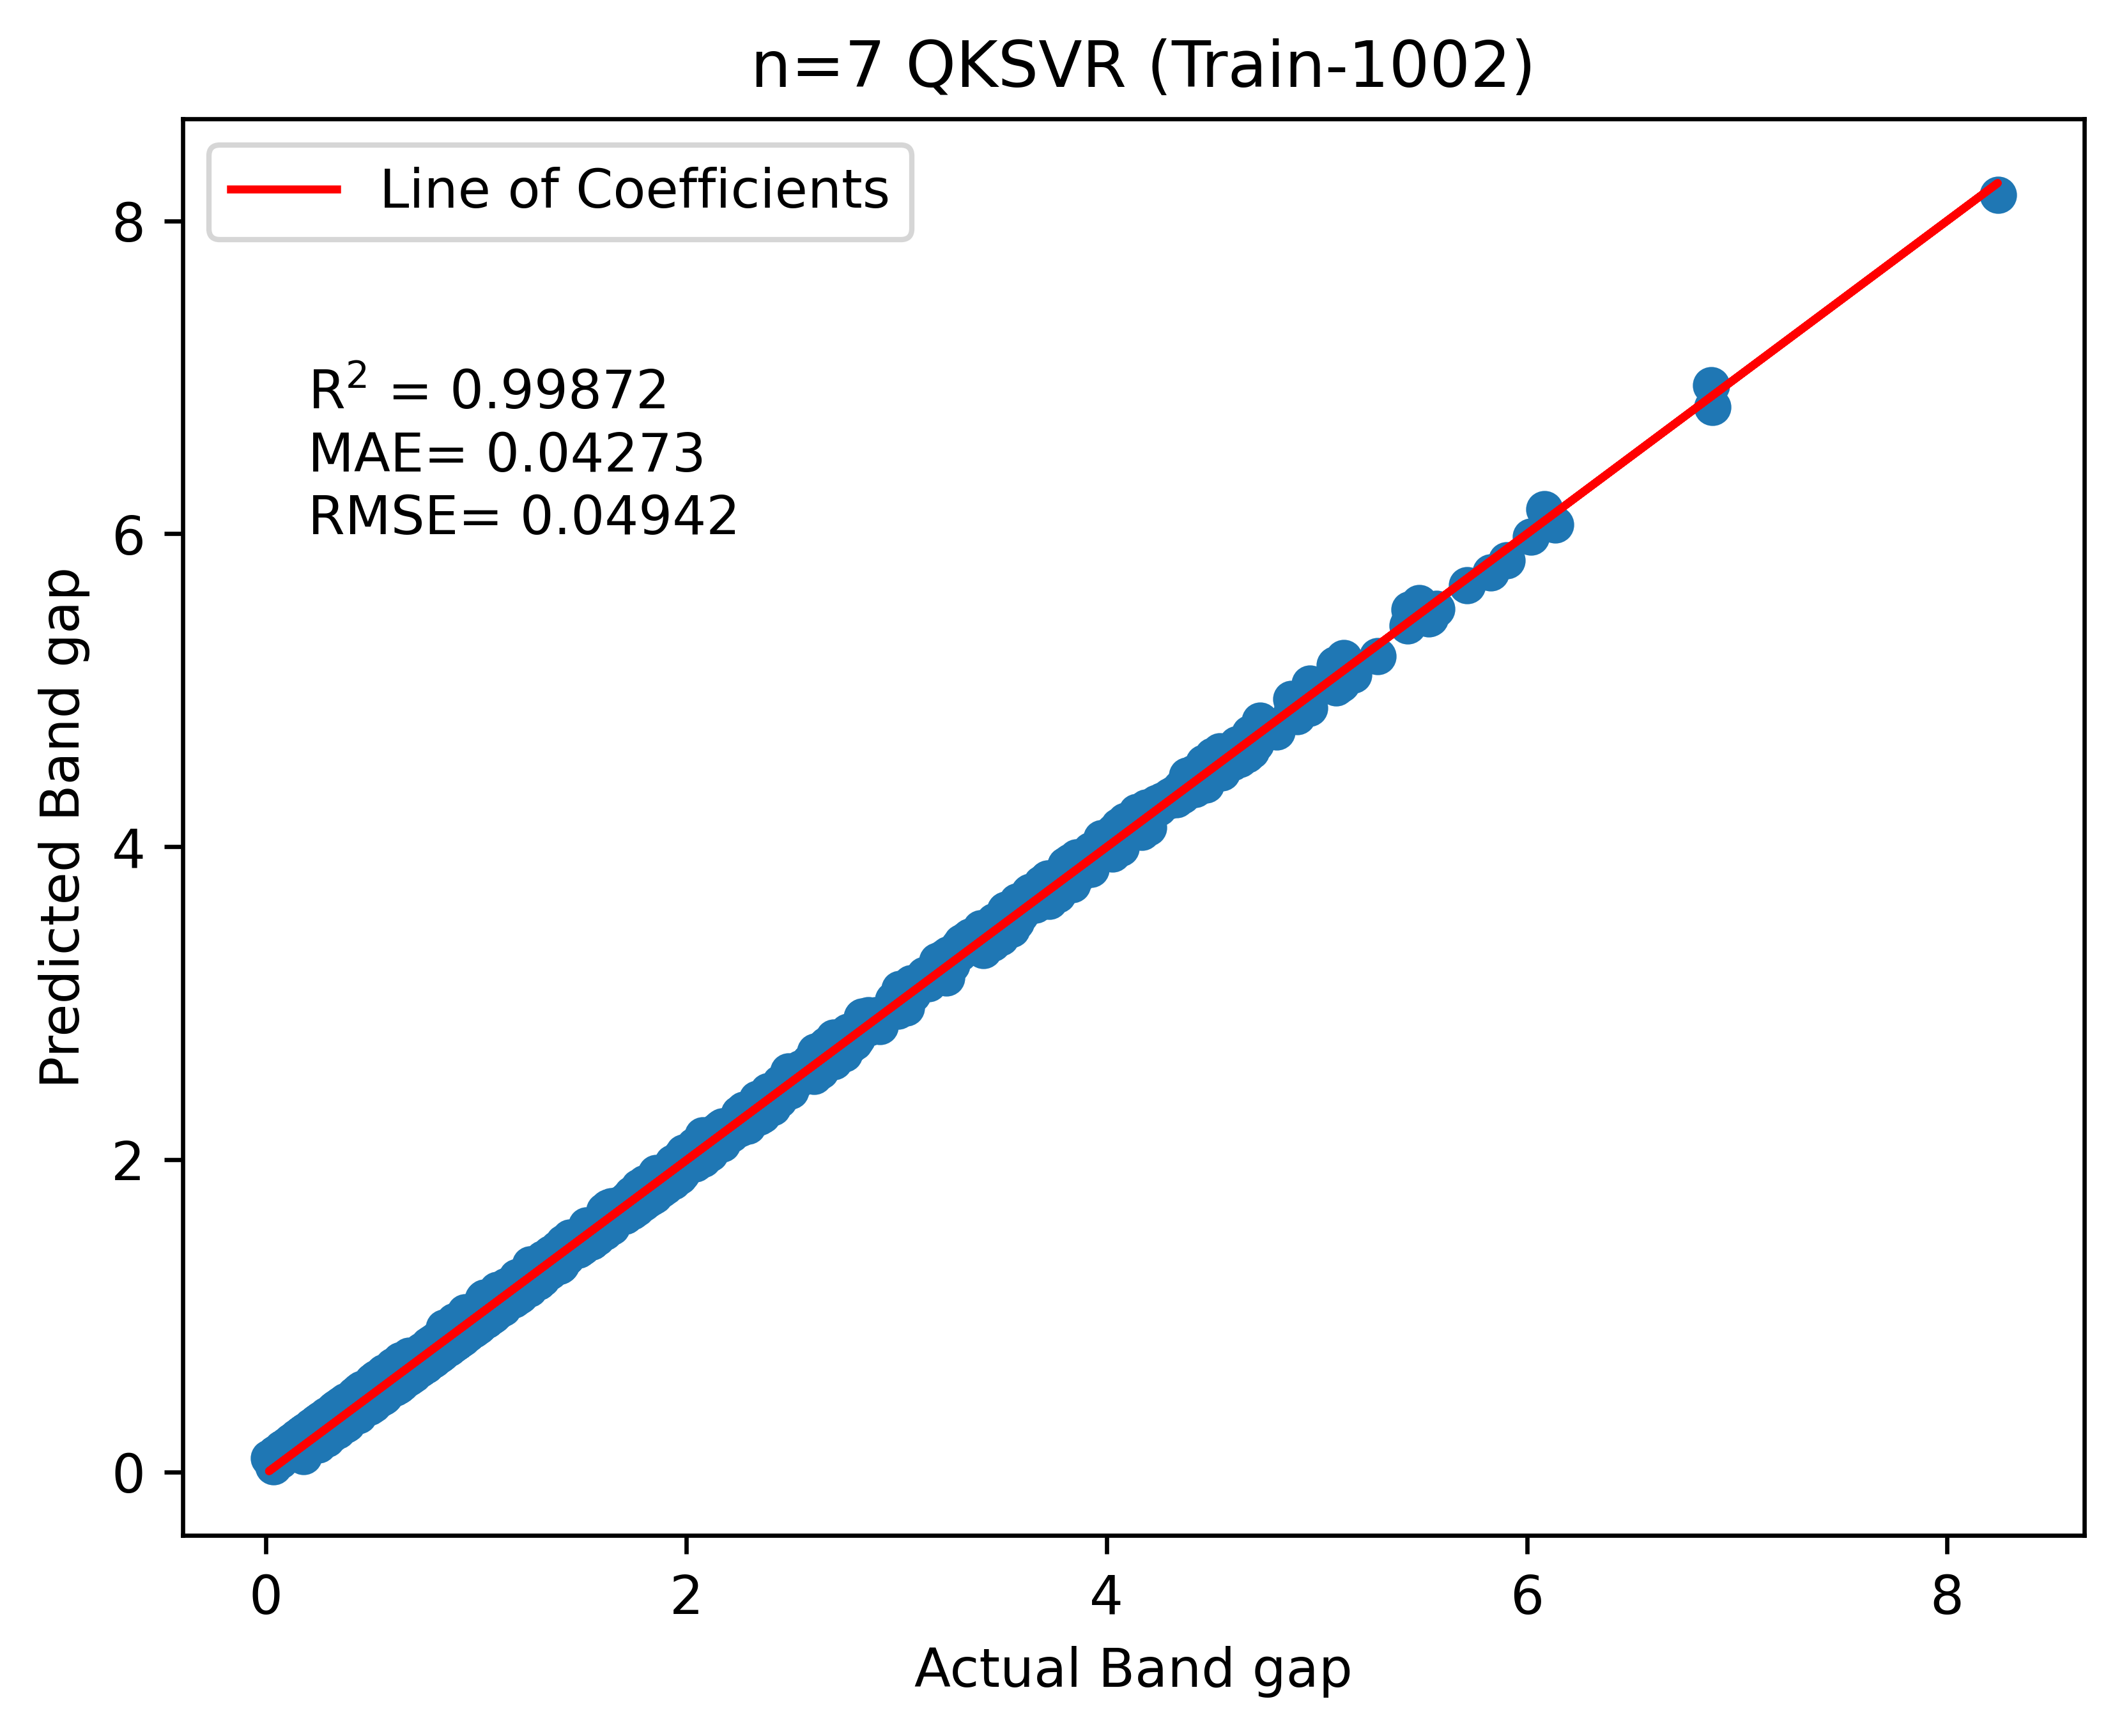

In [31]:
y_predtrain= svr.predict(K_train)
import numpy as np
from sklearn.ensemble import *
from sklearn.metrics import *
from sklearn.model_selection import *
import pandas as pd
## lgbm optimization
import numpy as np
import pandas as pd

from sklearn import ensemble
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
print('train r^2:',r2_score(y_train,y_predtrain))
print('train MAE', mean_absolute_error(y_train,y_predtrain))
print('train RMSE:',np.sqrt(mean_squared_error(y_train,y_predtrain)))
# Plot straight line
plt.figure(dpi=600)
plt.scatter(y_train,y_predtrain)
coefficients = np.polyfit(y_train,y_predtrain, 1)
line = np.polyval(coefficients, y_train)
plt.plot(y_train, line, color='r', label='Line of Coefficients')
# Plot straight line
plt.plot(y_train, line, color='r',)
plt.xlabel("Actual Band gap")
plt.ylabel("Predicted Band gap")
plt.annotate("R$^2$ = {:.5f}".format(r2_score(y_train,y_predtrain)), (0.2, 6.80))
plt.annotate("MAE= {:.5f}".format(mean_absolute_error(y_train,y_predtrain)), (0.2, 6.4))
plt.annotate("RMSE= {:.5f}".format(np.sqrt(mean_squared_error(y_train,y_predtrain))), (0.2, 6.0))
plt.title(" n=7 QKSVR (Train-1002)")#title
plt.legend()

In [5]:
df_true50=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\TRUE-50-EXTERNAL DATA.csv",encoding='ISO-8859–1')    
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y2 = df_true50['Band gap ']

# defining target
x2=df_true50[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test2= scaler.transform(x2)

# Compute the test kernel matrix (train-test kernel)
K_test2 = np.zeros((len(x_test2), len(X_train_scaled)))
for i in range(len(x_test2)):
    for j in range(len(X_train_scaled)):
        K_test2[i, j] = quantum_kernel(x_test2[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred2 = svr.predict(K_test2)
print("Predicted values:", y_pred2)

Predicted values: [1.49545214 1.30307436 1.05438062 0.51500458 1.79890327 1.35460836
 1.06676945 0.44090027 2.96556085 2.94705418 0.10436354 3.23486694
 2.32885455 0.36797954 1.38140626 0.43563003 0.32517445 2.90777797
 0.27101373 2.97865835 1.09651538 2.71342612 0.73390795 2.9604076
 1.93901861 0.88211798 2.08412519 1.59300254 2.31219426 2.53814396
 3.41781291 0.37717778 0.96483983 0.87092919 1.40043565 1.10204083
 0.11336617 4.29577617 3.39938712 0.34607708 2.84415546 4.21576229
 0.690559   0.47448639 0.70852792 0.78682214 1.50823113 2.4397976
 0.39117137 4.28646293]


Model evaluation - Test Set:
r^2: 0.9715522118752483
MAE 0.08405569372293481
RMSE: 0.2128115992685751


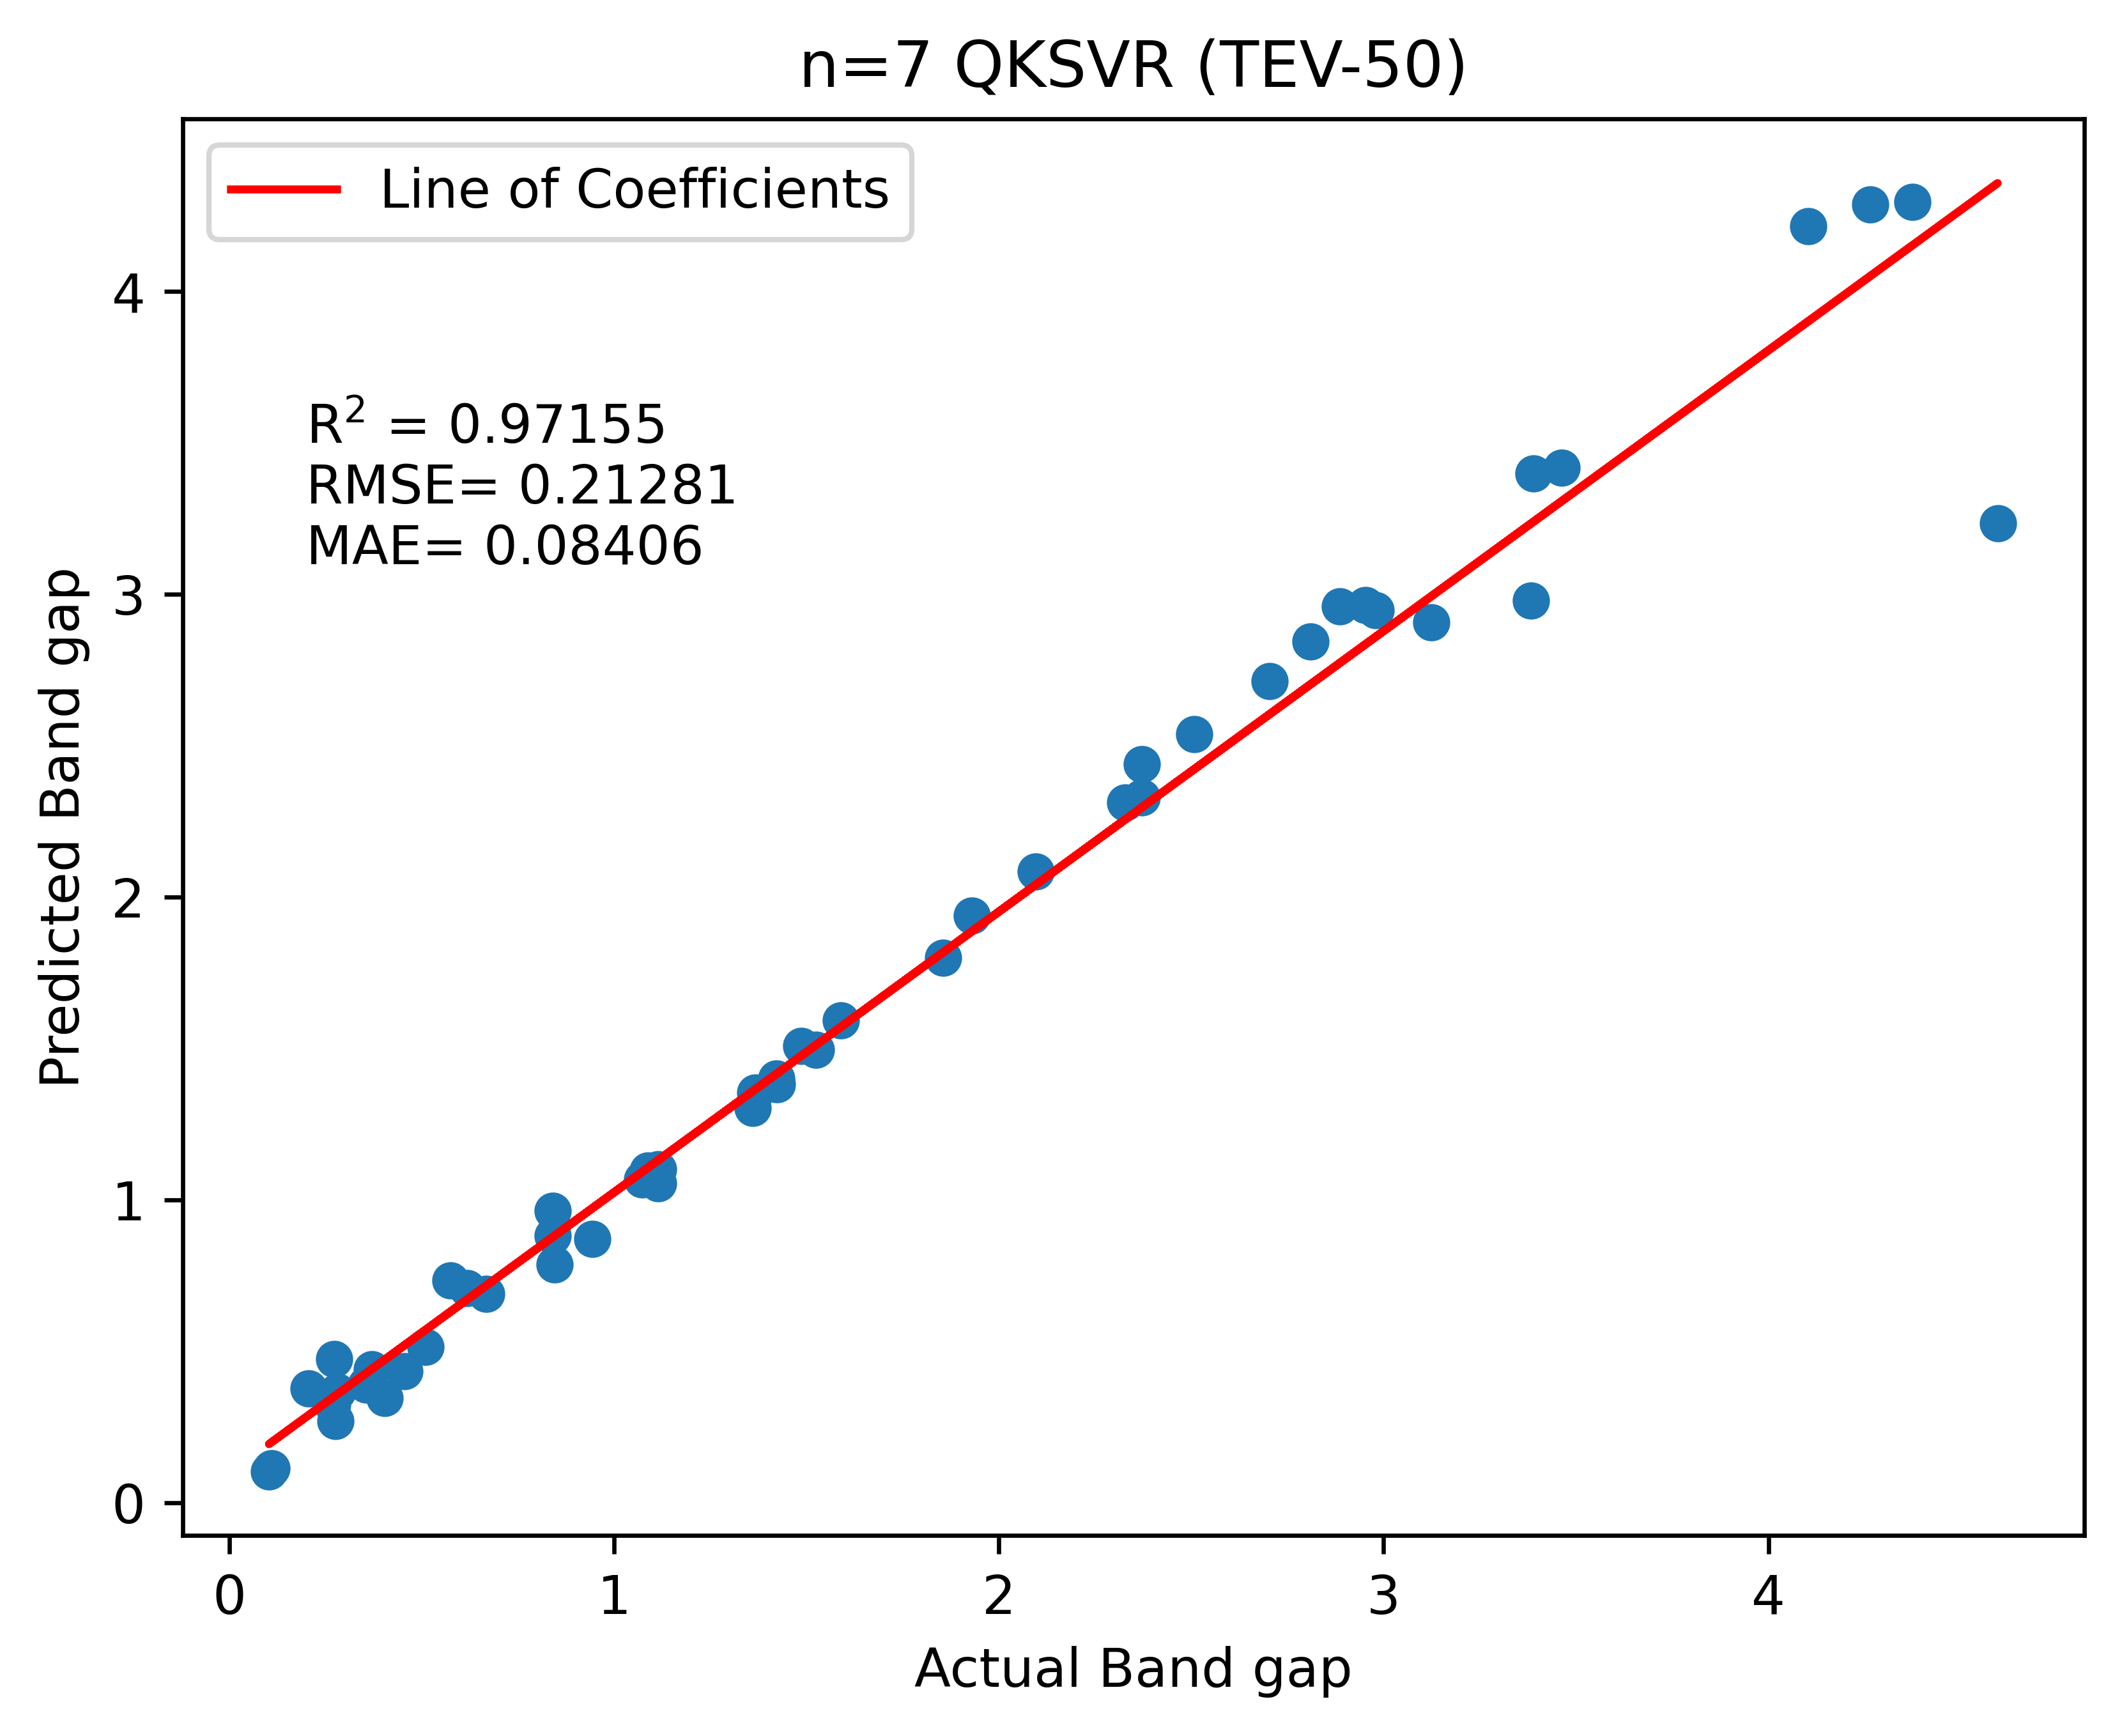

In [22]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y2, y_pred2))
print('MAE', mean_absolute_error(y2, y_pred2))
print('RMSE:',np.sqrt(mean_squared_error(y2, y_pred2)))
# Plot straight line
plt.figure(dpi=600)
plt.scatter(y2, y_pred2)
coefficients = np.polyfit(y2, y_pred2, 1)
line = np.polyval(coefficients, y2)
plt.plot(y2, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Band gap")
plt.ylabel("Predicted Band gap")
plt.annotate("R$^2$ = {:.5f}".format(r2_score(y2, y_pred2)), (0.2, 3.50))
plt.annotate("RMSE= {:.5f}".format(np.sqrt(mean_squared_error(y2, y_pred2))), (0.2, 3.30))
plt.annotate("MAE= {:.5f}".format(mean_absolute_error(y2, y_pred2)), (0.2, 3.10))
plt.title("n=7 QKSVR (TEV-50)")#title
plt.legend()

In [7]:
df3=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\TRUE-100-EXTERNAL DATA.csv",encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y3 = df3['Band gap ']

# defining target
x3=df3[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test3= scaler.transform(x3)

# Compute the test kernel matrix (train-test kernel)
K_test3 = np.zeros((len(x_test3), len(X_train_scaled)))
for i in range(len(x_test3)):
    for j in range(len(X_train_scaled)):
        K_test3[i, j] = quantum_kernel(x_test3[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred3 = svr.predict(K_test3)
print("Predicted values:", y_pred3)

Predicted values: [2.78009855 4.88177487 3.72829388 1.41306495 5.15311591 2.85668262
 5.94839418 1.79006117 0.67303087 0.32974123 0.34385818 0.46169925
 0.25645139 0.37664886 0.28008745 2.32960564 0.50550743 0.59488744
 2.11254032 2.32309107 2.73554203 0.10464935 0.99147988 1.22963285
 0.70641384 0.75266197 3.85347112 5.59580947 2.07927352 2.64161467
 4.0037139  6.01270614 4.18019096 1.8589143  2.0151665  0.00846701
 0.83420843 1.45264187 1.04796174 3.51917922 1.07680836 0.85346793
 0.47622024 1.21554829 2.17856038 1.48443258 1.45617454 0.18665832
 1.0850968  1.65069438 0.37331113 0.8248474  0.17632442 0.60381054
 0.30707309 1.29258162 2.35315262 0.9283541  0.82150475 5.97098975
 5.98538738 0.9878471  1.09037008 1.97205192 1.55004618 2.57409325
 4.60510627 1.94169369 1.5830316  3.50925591 0.4814972  3.81701863
 1.05575748 2.01519448 0.79535516 4.56626859 2.85579704 0.84620106
 1.79705392 1.16683598 0.71521883 0.4545723  0.66078018 1.83262712
 0.67944266 0.46386071 2.78378357 1.20135113

Model evaluation - Test Set:
r^2: 0.9977808926348105
MAE 0.05062648213686506
RMSE: 0.07470730615774474


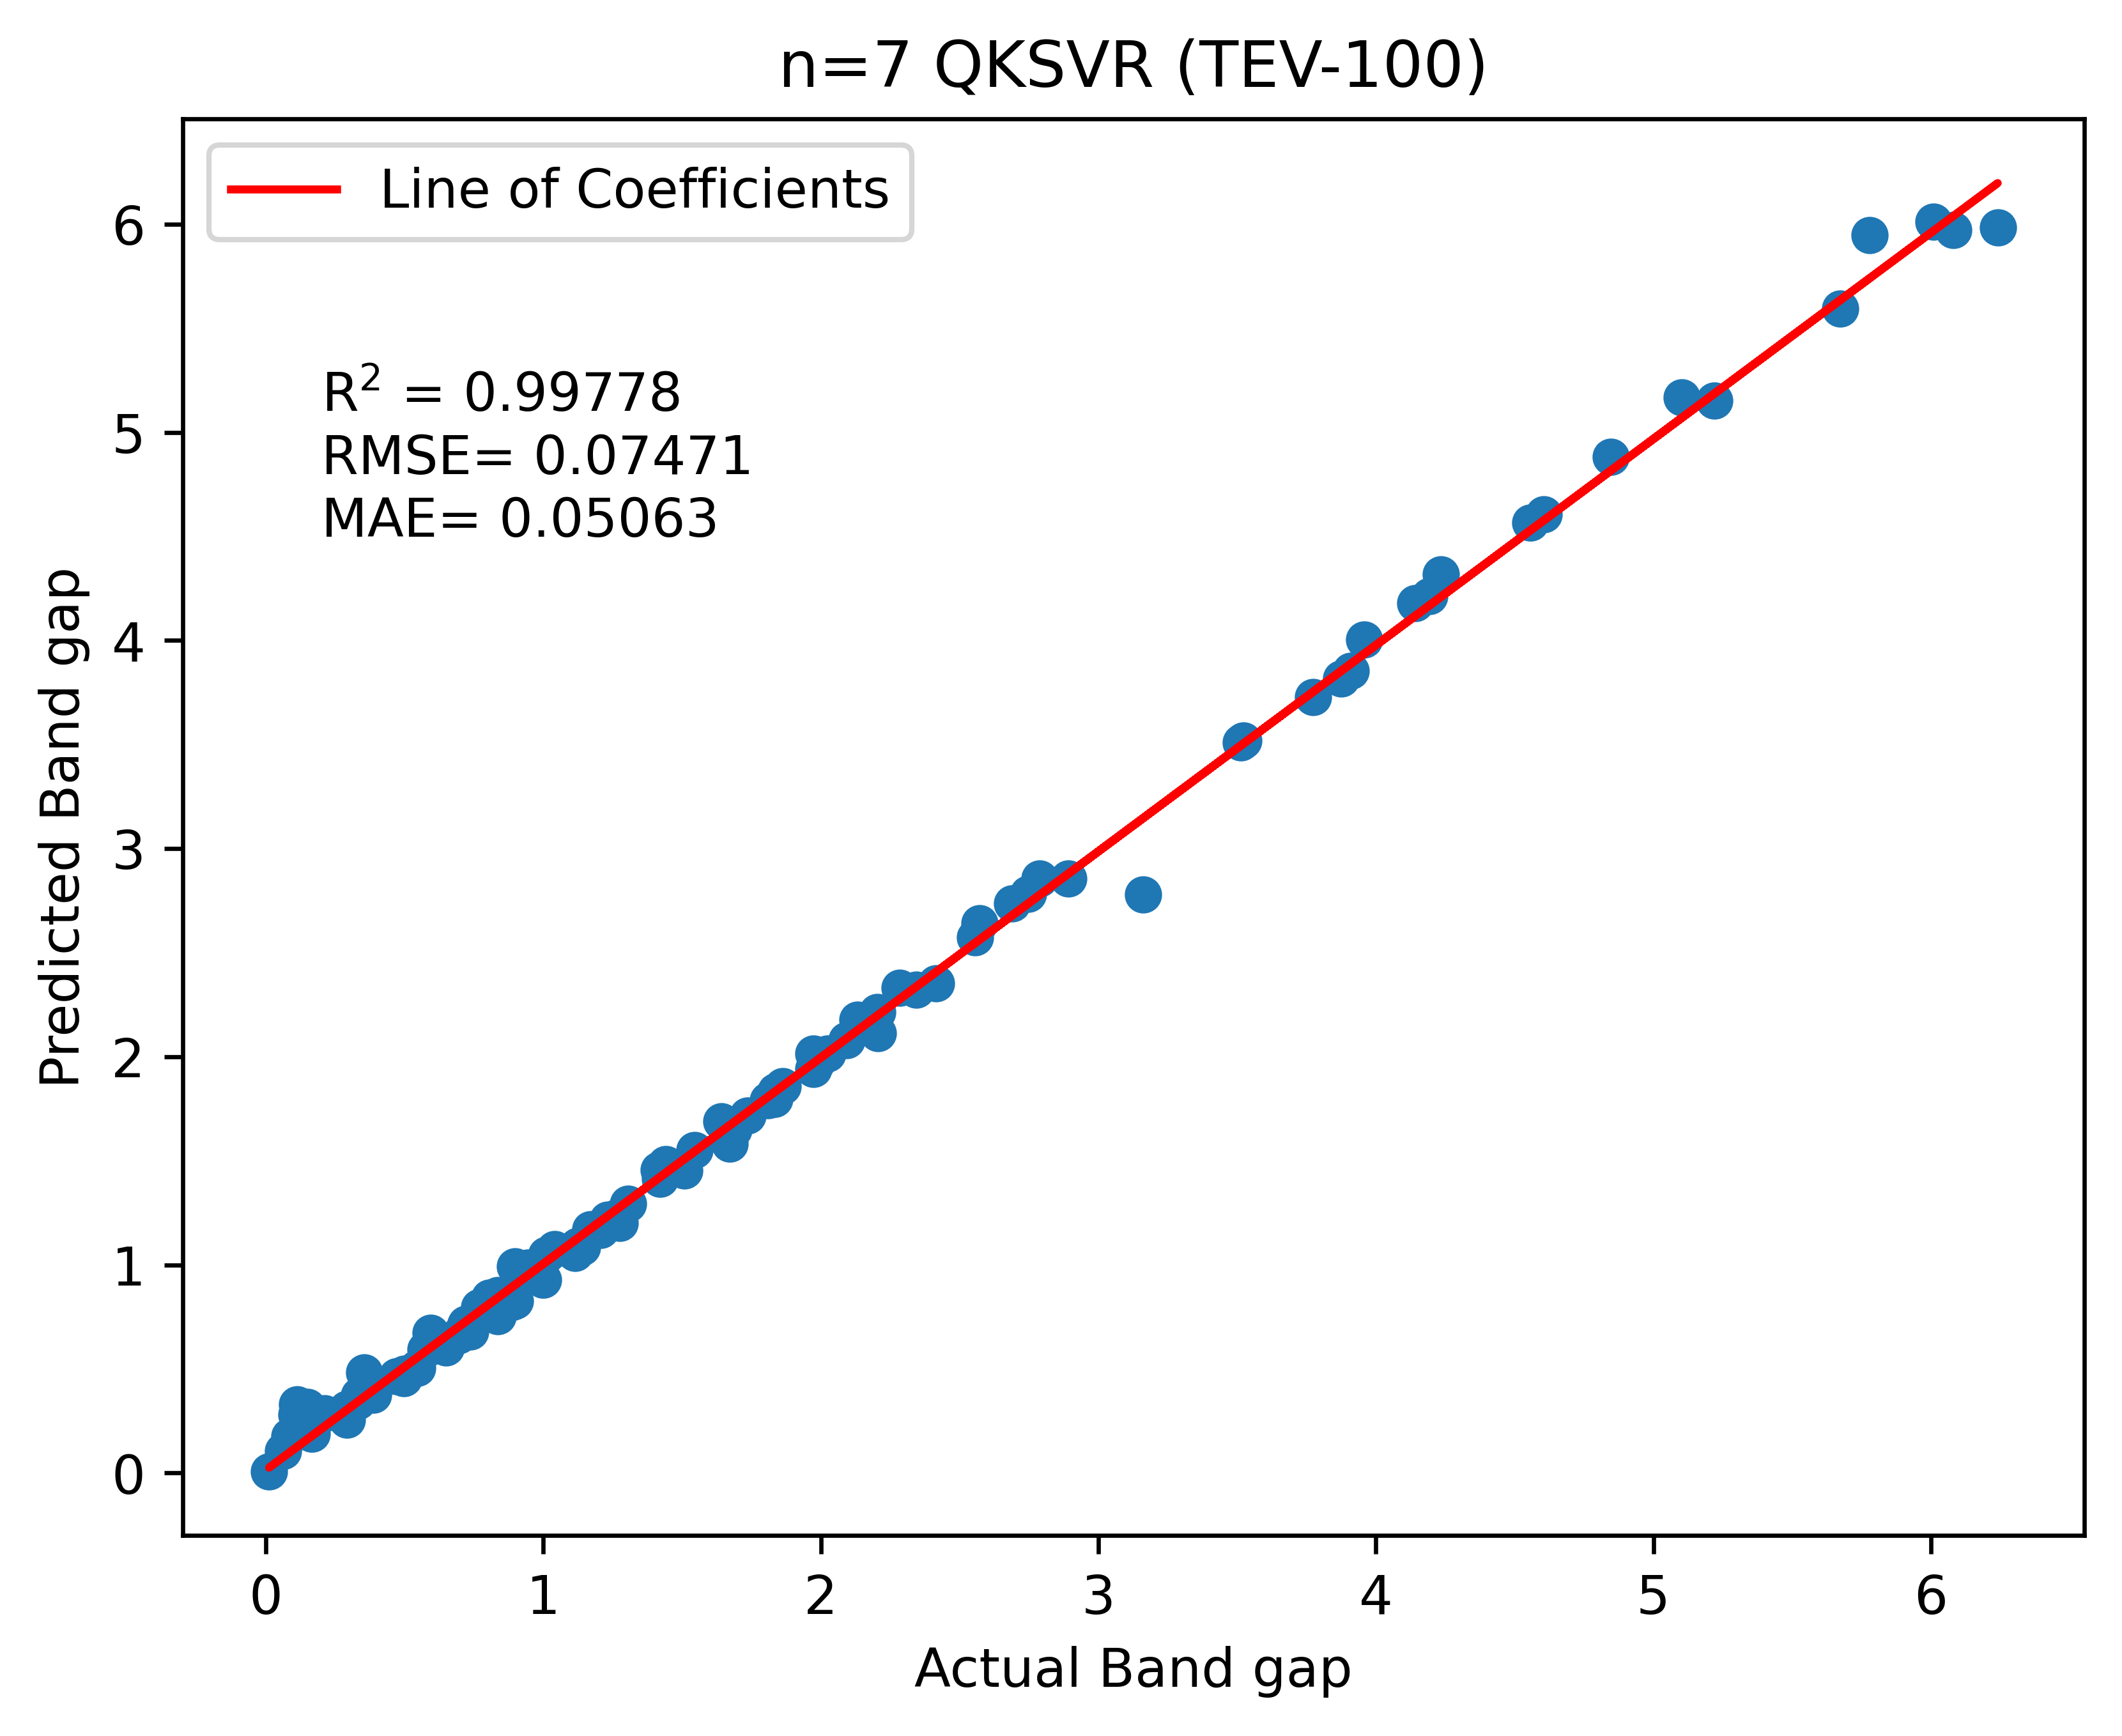

In [21]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y3, y_pred3))
print('MAE', mean_absolute_error(y3, y_pred3))
print('RMSE:',np.sqrt(mean_squared_error(y3, y_pred3)))
# Plot straight line
plt.figure(dpi=600)
plt.scatter(y3, y_pred3)
coefficients = np.polyfit(y3, y_pred3, 1)
line = np.polyval(coefficients, y3)
plt.plot(y3, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Band gap")
plt.ylabel("Predicted Band gap")
plt.annotate("R$^2$ = {:.5f}".format(r2_score(y3, y_pred3)), (0.2, 5.1))
plt.annotate("RMSE= {:.5f}".format(np.sqrt(mean_squared_error(y3, y_pred3))), (0.2, 4.8))
plt.annotate("MAE= {:.5f}".format(mean_absolute_error(y3, y_pred3)), (0.2, 4.5))
plt.title("n=7 QKSVR (TEV-100)")#title
plt.legend()

In [9]:

df4=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\TRUE-250-EXTERNAL DATA.csv",encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y4 = df4['Band gap ']

# defining target
x4=df4[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test4= scaler.transform(x4)

# Compute the test kernel matrix (train-test kernel)
K_test4 = np.zeros((len(x_test4), len(X_train_scaled)))
for i in range(len(x_test4)):
    for j in range(len(X_train_scaled)):
        K_test4[i, j] = quantum_kernel(x_test4[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred4 = svr.predict(K_test4)
print("Predicted values:", y_pred4)

Predicted values: [1.13988684 4.90856083 3.2320535  0.59463826 3.21044792 2.33205306
 2.64194809 0.7288351  0.72298568 6.20815914 0.3019588  5.38343218
 3.2522416  0.25156404 0.12970592 0.24534147 4.65363392 0.65777141
 0.48298331 2.99380623 4.18922374 0.29713942 7.4857126  1.36905397
 0.89841605 0.82100818 3.10211264 2.41254533 2.14326661 1.77467925
 1.07118542 0.91465023 0.68723766 0.69847744 0.7642065  1.55956112
 0.80214439 1.33687082 1.69496753 3.35375323 0.79052795 0.83538966
 0.32204295 1.02017344 0.86702711 3.84048424 0.44603623 0.90364151
 1.69824151 0.71416598 0.56401389 1.51836631 0.28028108 0.74757099
 0.80101625 1.96988592 0.30429526 0.99705235 0.8934044  1.39522301
 0.58410807 0.91498755 2.40710507 0.67301193 0.68472338 1.02631905
 0.83527363 0.96524861 4.26865698 1.66223573 0.28424598 3.92988012
 1.58115335 1.55615387 0.09347192 0.60355562 0.37613804 0.7980841
 0.49532826 1.17676392 2.22002375 0.30603942 2.66047626 1.107471
 1.84102986 1.27026712 0.99734465 3.94786583 0.

Model evaluation - Test Set:
r^2: 0.9927002699163492
MAE 0.06299151071658006
RMSE: 0.12498625714256521


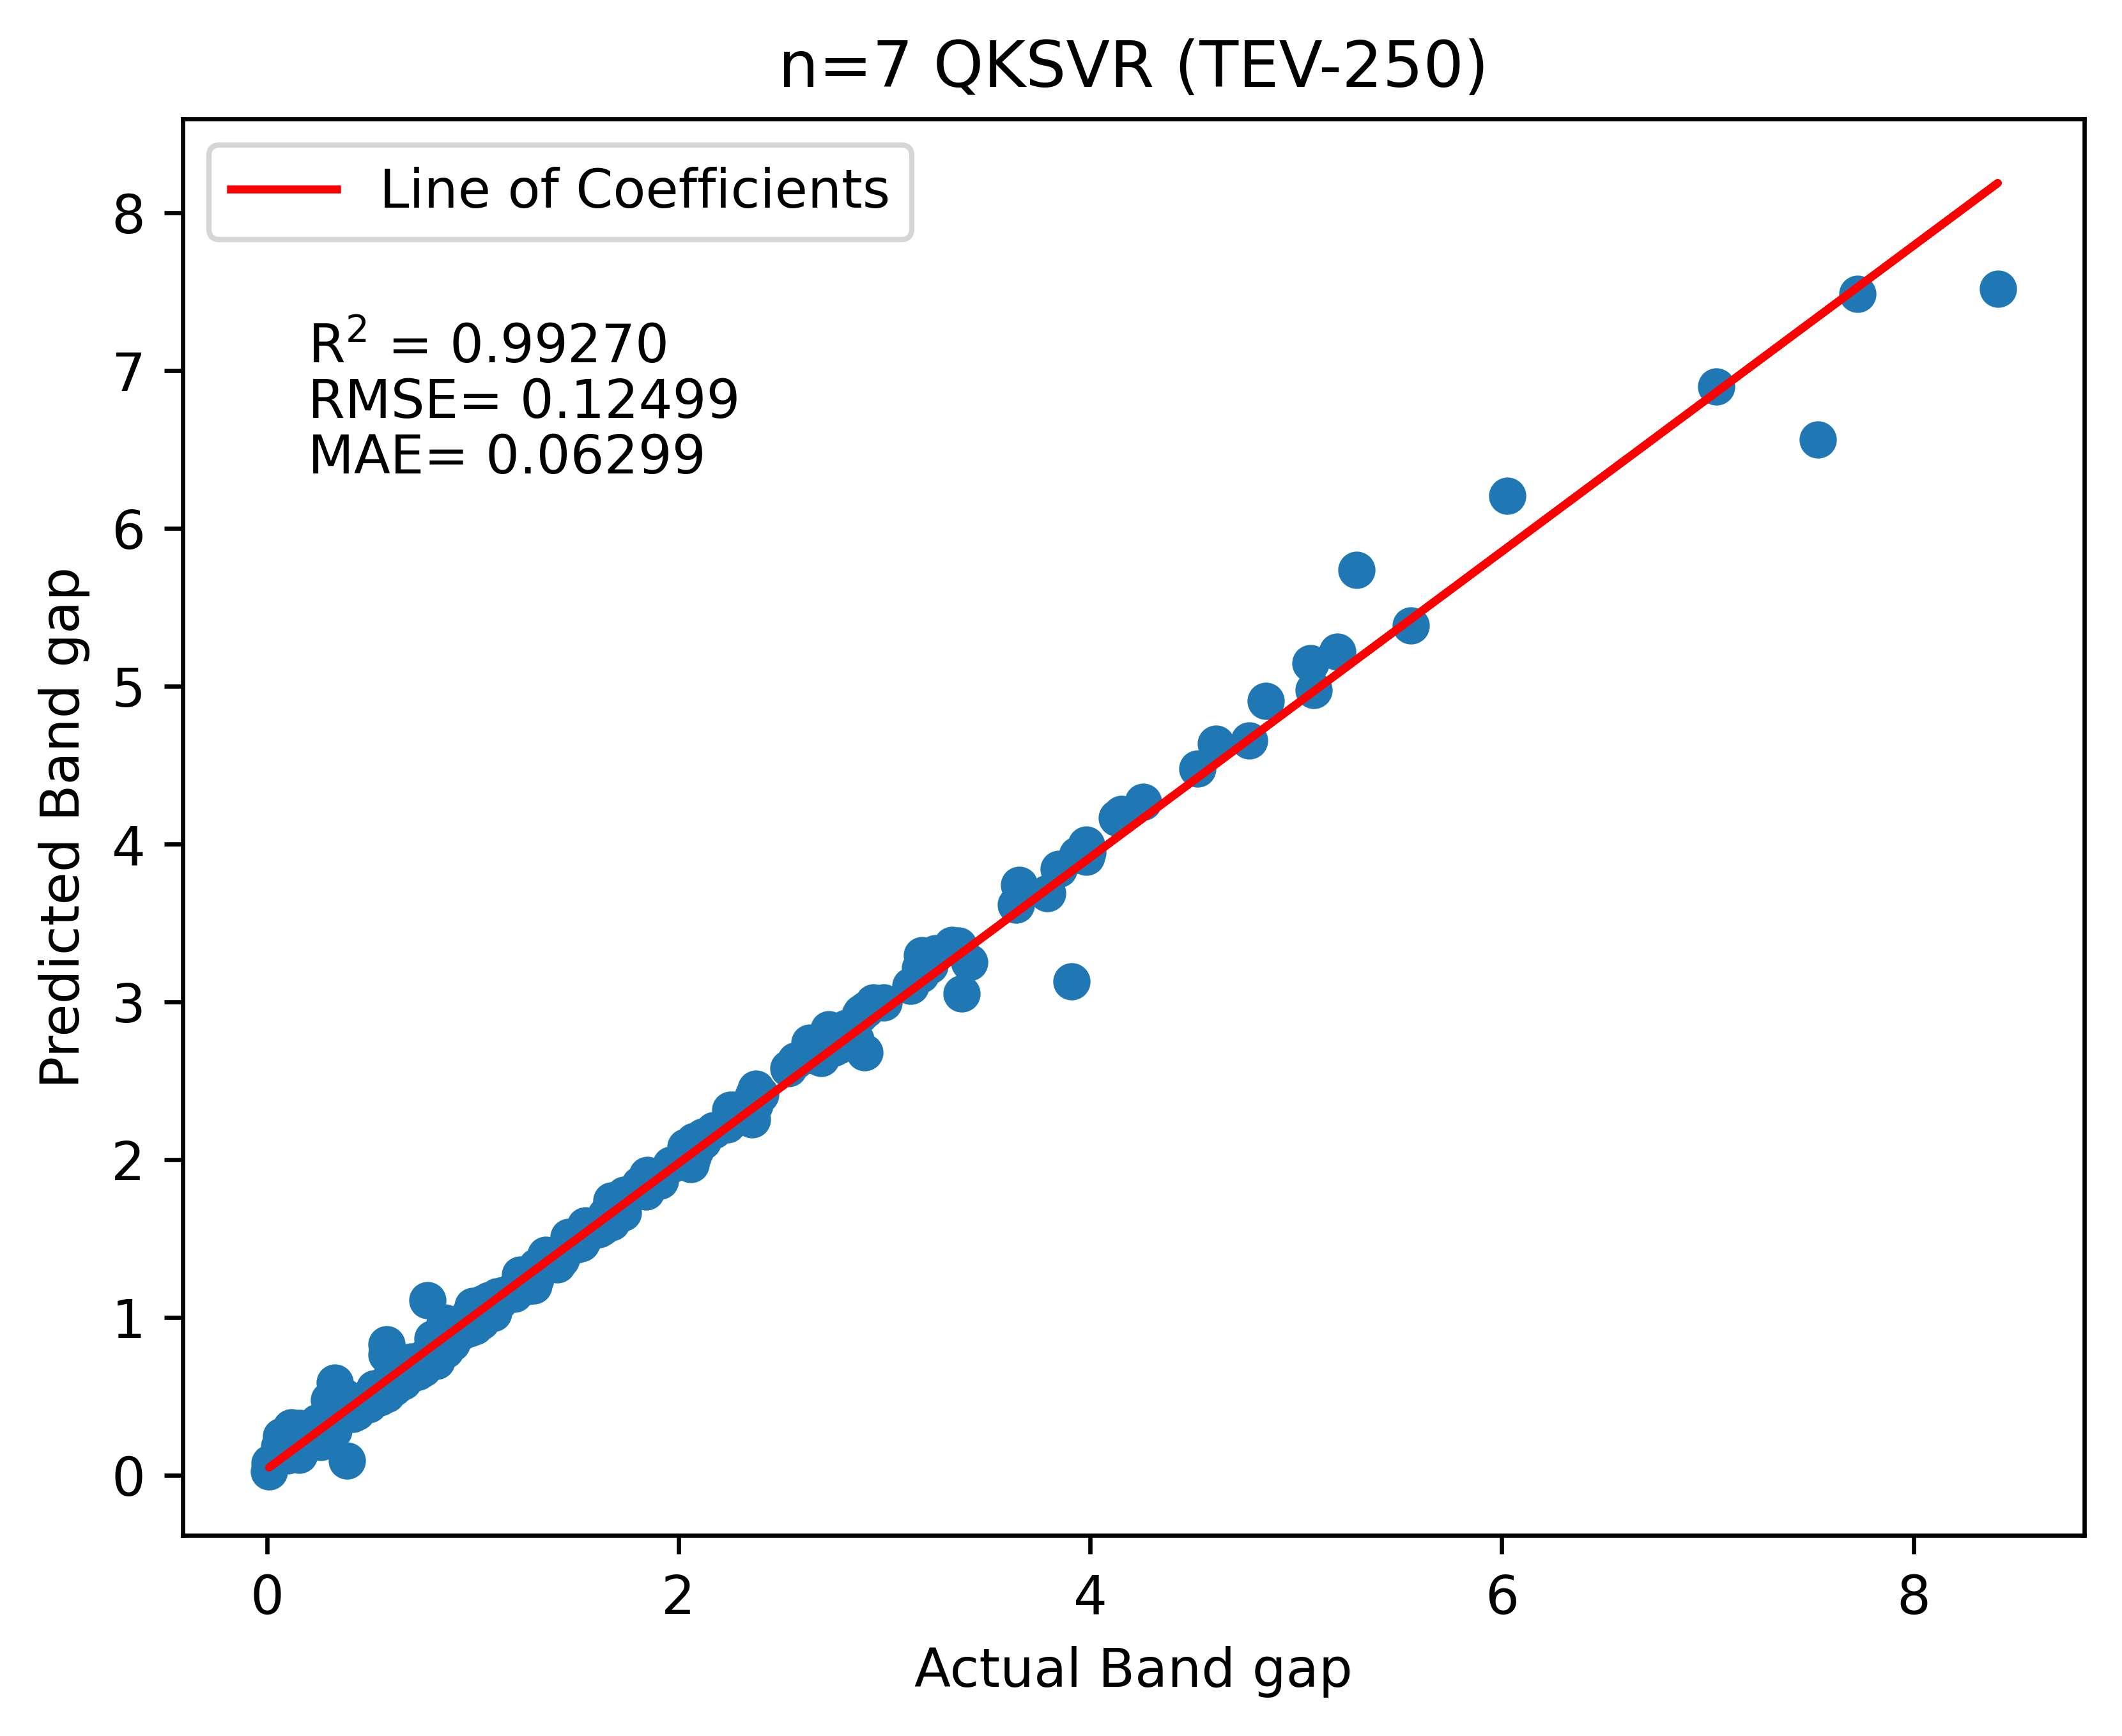

In [25]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y4, y_pred4))
print('MAE', mean_absolute_error(y4, y_pred4))
print('RMSE:',np.sqrt(mean_squared_error(y4, y_pred4)))
# Plot straight line
plt.figure(dpi=600)
plt.scatter(y4, y_pred4)
coefficients = np.polyfit(y4, y_pred4, 1)
line = np.polyval(coefficients, y4)
plt.plot(y4, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Band gap")
plt.ylabel("Predicted Band gap")
plt.annotate("R$^2$ = {:.5f}".format(r2_score(y4, y_pred4)), (0.2, 7.05))
plt.annotate("RMSE= {:.5f}".format(np.sqrt(mean_squared_error(y4, y_pred4))), (0.2, 6.70))
plt.annotate("MAE= {:.5f}".format(mean_absolute_error(y4, y_pred4)), (0.2, 6.35))
plt.title("n=7 QKSVR (TEV-250)")#title
plt.legend()

In [11]:
df5=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\TRUE-400-EXTERNAL DATA.csv",encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y5 = df5['Band gap ']

# defining target
x5=df5[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test5= scaler.transform(x5)

# Compute the test kernel matrix (train-test kernel)
K_test5 = np.zeros((len(x_test5), len(X_train_scaled)))
for i in range(len(x_test5)):
    for j in range(len(X_train_scaled)):
        K_test5[i, j] = quantum_kernel(x_test5[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred5 = svr.predict(K_test5)
print("Predicted values:", y_pred5)

Predicted values: [1.49545214 1.30307436 1.05438062 0.51500458 1.79890327 1.35460836
 1.06676945 0.44090027 2.96556085 2.94705418 0.10436354 3.23486694
 2.32885455 0.36797954 1.38140626 0.43563003 0.32517445 2.90777797
 0.27101373 2.97865835 1.09651538 2.71342612 0.73390795 2.9604076
 1.93901861 0.88211798 2.08412519 1.59300254 2.31219426 2.53814396
 3.41781291 0.37717778 0.96483983 0.87092919 1.40043565 1.10204083
 0.11336617 4.29577617 3.39938712 0.34607708 2.84415546 4.21576229
 0.690559   0.47448639 0.70852792 0.78682214 1.50823113 2.4397976
 0.39117137 4.28646293 2.78009855 4.88177487 3.72829388 1.41306495
 5.15311591 2.85668262 5.94839418 1.79006117 0.67303087 0.32974123
 0.34385818 0.46169925 0.25645139 0.37664886 0.28008745 2.32960564
 0.50550743 0.59488744 2.11254032 2.32309107 2.73554203 0.10464935
 0.99147988 1.22963285 0.70641384 0.75266197 3.85347112 5.59580947
 2.07927352 2.64161467 4.0037139  6.01270614 4.18019096 1.8589143
 2.0151665  0.00846701 0.83420843 1.45264187 1.

Model evaluation - Test Set:
r^2: 0.9922666690149737
MAE 0.06253327644744566
RMSE: 0.12969144263524085


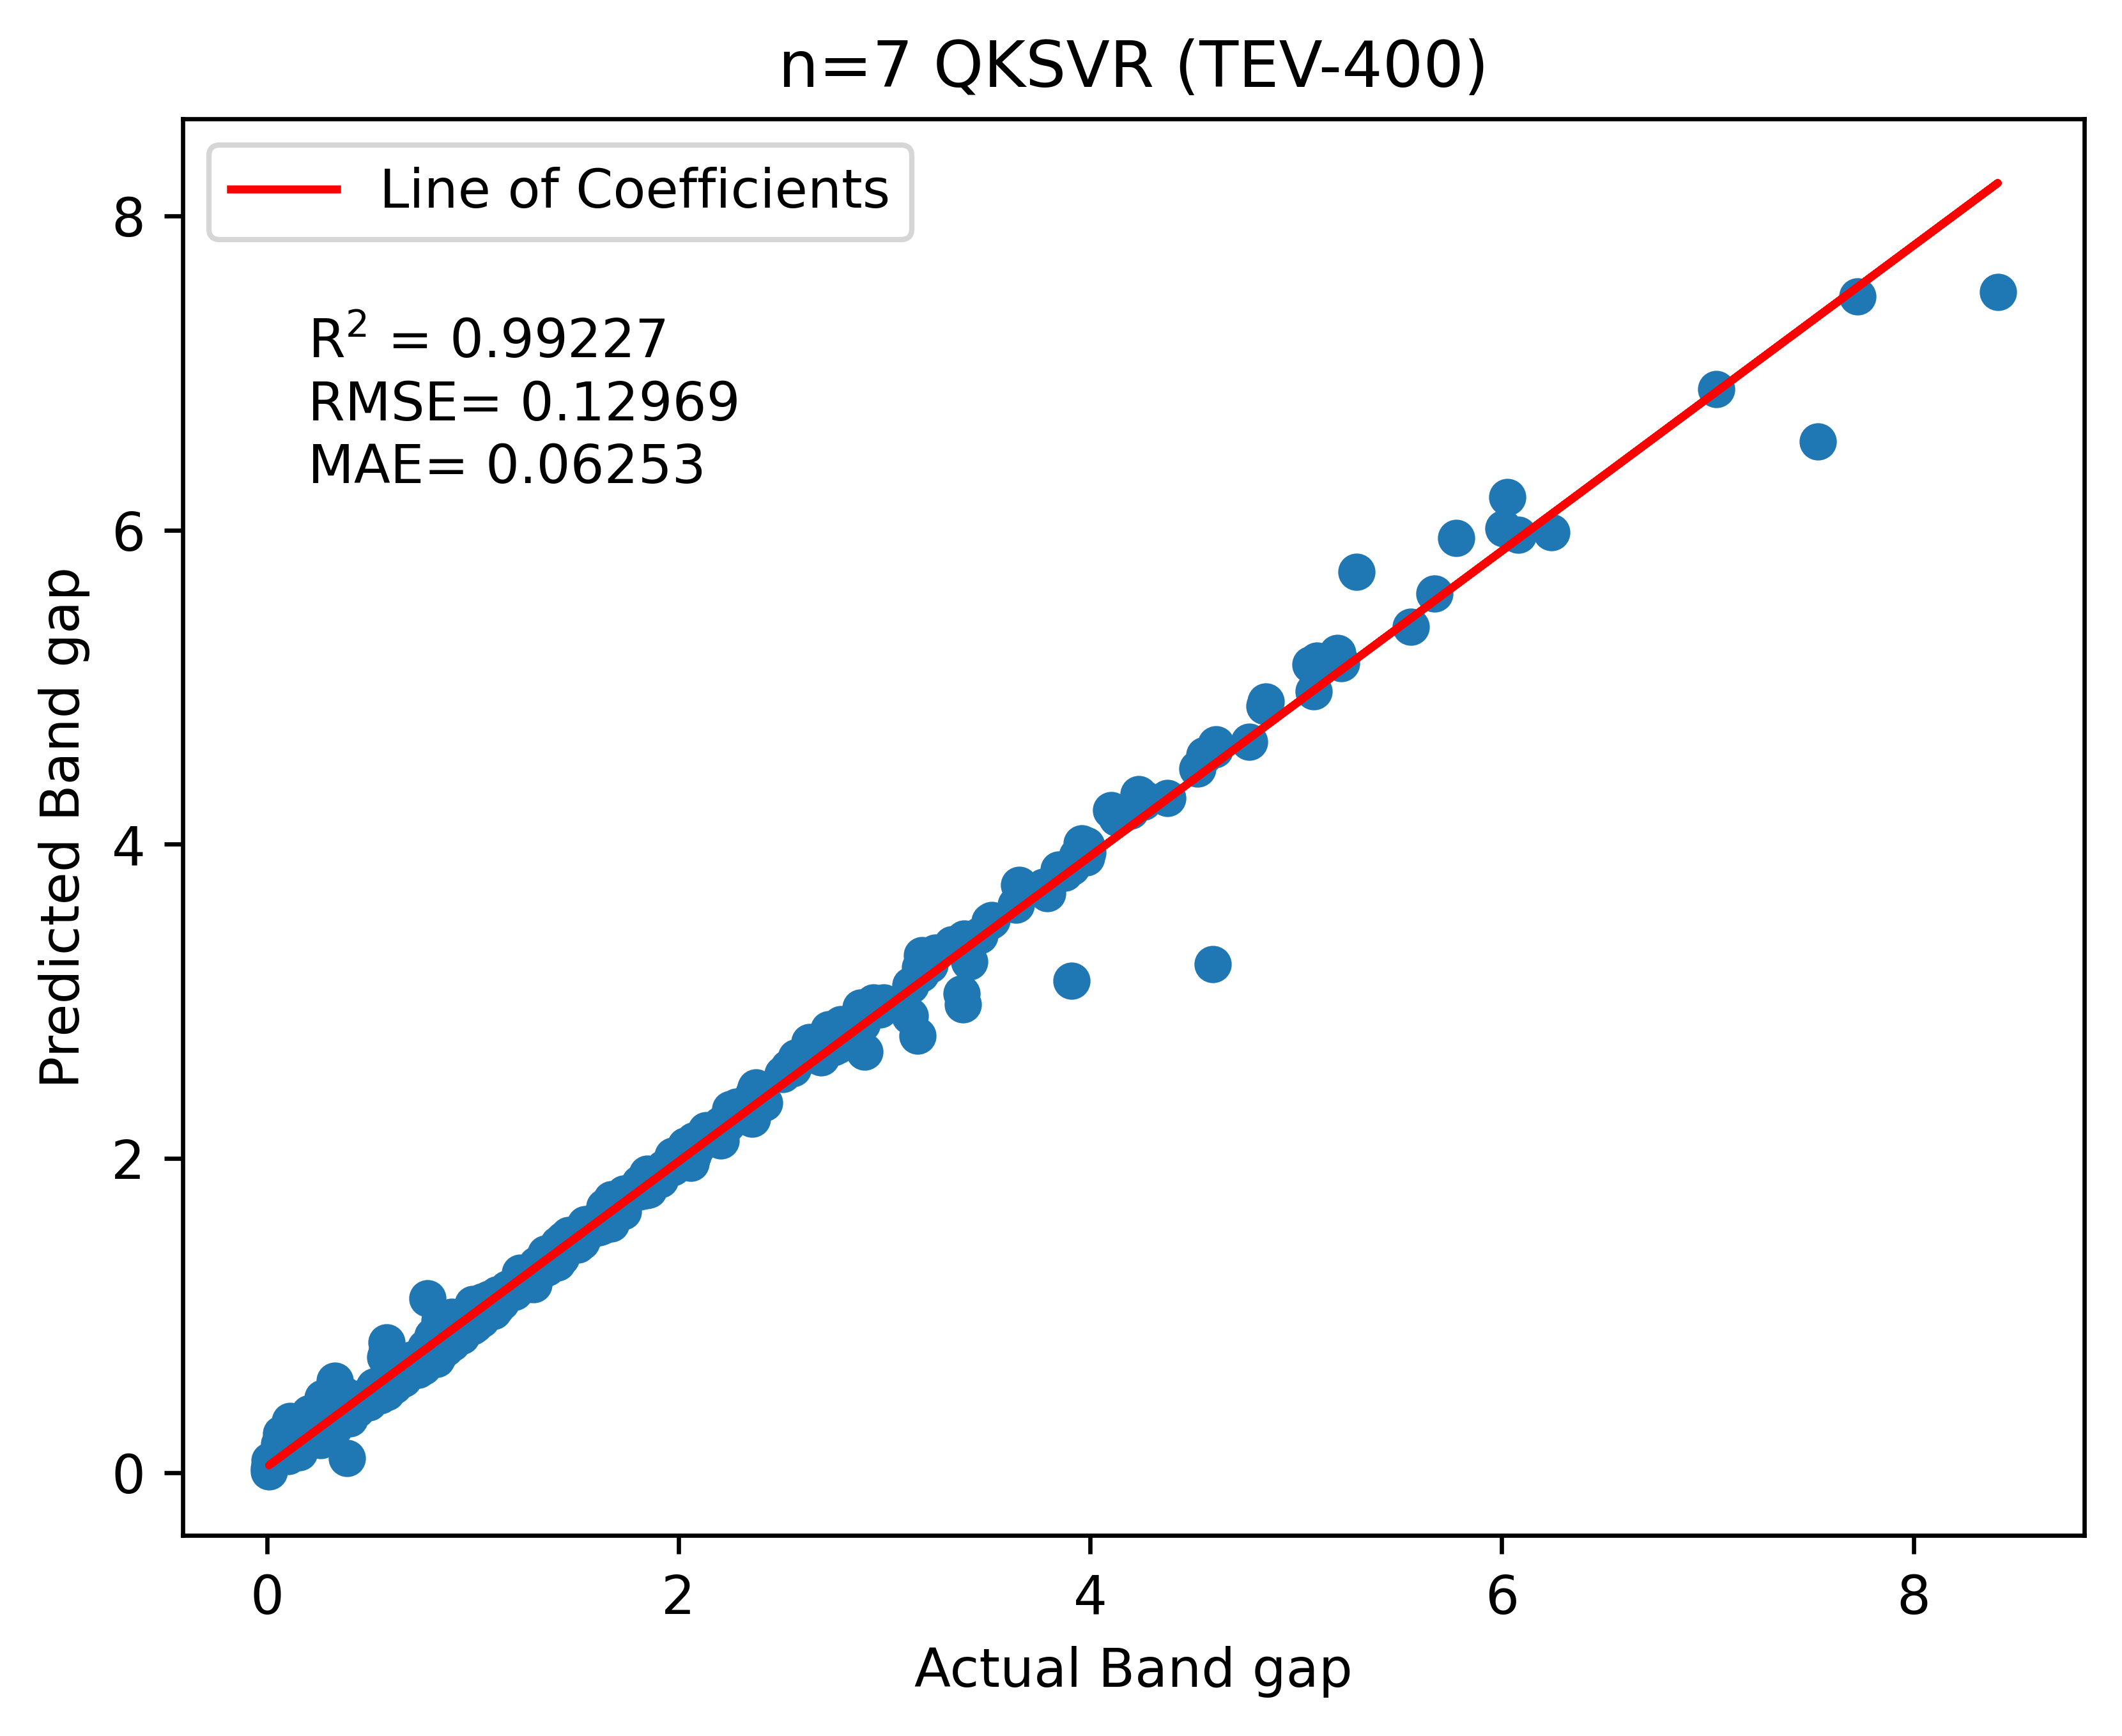

In [30]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y5, y_pred5))
print('MAE', mean_absolute_error(y5, y_pred5))
print('RMSE:',np.sqrt(mean_squared_error(y5, y_pred5)))
# Plot straight line
plt.figure(dpi=600)
plt.scatter(y5, y_pred5)
coefficients = np.polyfit(y5, y_pred5, 1)
line = np.polyval(coefficients, y5)
plt.plot(y5, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Band gap")
plt.ylabel("Predicted Band gap")
plt.annotate("R$^2$ = {:.5f}".format(r2_score(y5, y_pred5)), (0.2, 7.10))
plt.annotate("RMSE= {:.5f}".format(np.sqrt(mean_squared_error(y5, y_pred5))), (0.2, 6.700))
plt.annotate("MAE= {:.5f}".format(mean_absolute_error(y5, y_pred5)), (0.2, 6.3))
plt.title("n=7 QKSVR (TEV-400)")#title
plt.legend()